## Próximas etapas

Agora você pode:

1. **Executar o treinamento dos modelos sklearn** - As funções automáticamente logam tudo no MLflow
2. **Verificar os experimentos**:
   ```python
   listar_experimentos_mlflow()  # Lista todos os experimentos
   comparar_modelos_mlflow()     # Compara performance dos modelos
   ```
3. **Iniciar o MLflow UI** (em um terminal):
   ```bash
   cd c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis
   mlflow ui --backend-store-uri file:///$(pwd)/mlruns
   ```
   Depois acesse `http://localhost:5000`

**Estrutura de dados MLflow:**
- 📁 `mlruns/` → pasta com experimentos
- 📊 Cada experimento contém múltiplos "runs" (treinamentos)
- 📈 Cada run contém: parâmetros, métricas e artefatos (modelos)

In [73]:
# === Visualização de Experimentos MLflow ===

from mlflow.tracking.client import MlflowClient

def listar_experimentos_mlflow():
    """Lista todos os experimentos e runs do MLflow"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Listar todos os experimentos
    experiments = client.search_experiments()
    print(f"Total de experimentos: {len(experiments)}\n")
    
    for exp in experiments:
        print(f"📊 Experimento: {exp.name} (ID: {exp.experiment_id})")
        
        # Listar runs deste experimento
        runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=10)
        print(f"   Runs: {len(runs)}")
        
        for run in runs[:5]:  # Mostrar apenas os 5 primeiros
            status = "✅" if run.info.status == "FINISHED" else "⏳"
            rmse = run.data.metrics.get("rmse", None)
            rmse_str = f"{rmse:.4f}" if rmse else "N/A"
            print(f"   {status} {run.info.run_name} - RMSE: {rmse_str}")
        
        if len(runs) > 5:
            print(f"   ... e mais {len(runs) - 5} runs")
        print()
        
def _find_mlflow_experiment(client, experiment_name):
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment:
        return experiment

    experiments = client.search_experiments()
    matches = [
        exp for exp in experiments
        if exp.name == experiment_name
        or exp.name.endswith(experiment_name)
        or experiment_name in exp.name
    ]

    if len(matches) == 1:
        print(f"Usando experimento encontrado: {matches[0].name} (ID: {matches[0].experiment_id})")
        return matches[0]

    if len(matches) > 1:
        print(f"Vários experimentos correspondem a '{experiment_name}':")
        for exp in matches:
            print(f" - {exp.name} (ID: {exp.experiment_id})")
        print(f"Usando o primeiro experimento: {matches[0].name}")
        return matches[0]

    return None


def comparar_modelos_mlflow(EXPERIMENTO_NOME):
    """Compara métricas de todos os modelos treinados"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Buscar runs do experimento atual
    experiment = _find_mlflow_experiment(client, EXPERIMENTO_NOME)
    if not experiment:
        print(f"Experimento '{EXPERIMENTO_NOME}' não encontrado")
        return
    
    runs = client.search_runs(experiment_ids=[experiment.experiment_id], max_results=100)
    
    # Criar DataFrame com resultados
    resultados = []
    for run in runs:
        if run.data.metrics:
            resultados.append({
                "run_name": run.info.run_name,
                "rmse": run.data.metrics.get("rmse"),
                "mae": run.data.metrics.get("mae"),
                "mape": run.data.metrics.get("mape"),
                "r2": run.data.metrics.get("r2"),
                "parametros": run.data.params,
                "feature_sampled": run.data.tags.get("feature_sample"),
                "modelo": run.data.tags.get("modelo"),
                "status": run.info.status,
            })
    
    df_comparacao = pd.DataFrame(resultados).sort_values("rmse", na_position="last")
    if df_comparacao.empty:
        print(f"Nenhum run com métricas encontrado para o experimento '{experiment.name}' (ID: {experiment.experiment_id}).")
    else:
        print("Comparação de modelos treinados:")
        print(df_comparacao.to_string(index=False))
    
    return df_comparacao

### Como usar MLflow

**Exemplos de uso:**

1. **Treinar modelo sklearn com logging MLflow:**
   ```python
   modelo = RandomForestRegressor(n_estimators=200)
   pipe, metricas = treinar_pipeline_com_mlflow(
       "rf_modelo_v1", modelo, X_train, y_train, X_test, y_test, criar_preprocessador
   )
   ```

2. **Otimizar MLP com Optuna + MLflow:**
   ```python
   study, best_mlp = otimizar_mlp_com_mlflow(
       n_trials=30, 
       X=X_train_keras, 
       y=y_train_log, 
       input_dim=X_train_keras.shape[1]
   )
   ```

3. **Visualizar experimentos no MLflow UI:**
   ```bash
   mlflow ui --backend-store-uri file://<seu-caminho>/mlruns
   ```

**Dados rastreados:**
- ✅ Hiperparâmetros do modelo
- ✅ Métricas (RMSE, MAE, MAPE, R²)
- ✅ Modelo serializado (`.pkl`, `.keras`)
- ✅ Metadados (target, n_features, etc)

In [ ]:
# === Funções auxiliares com MLflow logging ===

def _build_feature_store_definition(X, feature_group_name="joinville_imoveis", description=None, target=None, source=None):
    feature_names = []
    features = []

    if hasattr(X, "columns"):
        feature_names = list(X.columns)
    elif isinstance(X, np.ndarray) and X.ndim == 2:
        feature_names = [f"feature_{i}" for i in range(X.shape[1])]

    for idx, name in enumerate(feature_names):
        feature_info = {
            "name": name,
            "index": idx,
            "is_feature": True,
            "is_target": name == target,
            "is_categorical": name in CATEGORICAL_FEATURES,
            "is_numeric": False,
            "dtype": "unknown",
            "null_count": None,
            "unique_count": None,
            "sample_values": [],
        }

        if hasattr(X, "columns"):
            series = X[name]
            feature_info["dtype"] = str(series.dtype)
            feature_info["null_count"] = int(series.isna().sum())
            feature_info["unique_count"] = int(series.nunique(dropna=False))
            feature_info["sample_values"] = series.dropna().astype(str).unique()[:5].tolist()
            feature_info["is_numeric"] = pd.api.types.is_numeric_dtype(series)

            if feature_info["is_numeric"]:
                feature_info.update({
                    "mean": float(series.mean()) if series.count() else None,
                    "std": float(series.std()) if series.count() else None,
                    "min": float(series.min()) if series.count() else None,
                    "max": float(series.max()) if series.count() else None,
                })
            else:
                top_values = series.value_counts(dropna=False).head(5).to_dict()
                feature_info["top_values"] = {str(k): int(v) for k, v in top_values.items()}

        features.append(feature_info)

    feature_store = {
        "feature_group_name": feature_group_name,
        "description": description or "Metadata do conjunto de features usado para treinar o modelo",
        "target": target,
        "source": source,
        "feature_count": len(feature_names),
        "features": features,
    }

    return feature_store


def _log_feature_store(X, run_name=None, feature_group_name="joinville_imoveis", description=None, source=None):
    feature_store_definition = _build_feature_store_definition(
        X,
        feature_group_name=feature_group_name,
        description=description,
        target=TARGET,
        source=source,
    )

    feature_store_artifact = {
        "run_name": run_name,
        "feature_store": feature_store_definition,
        "logged_at": pd.Timestamp.now().isoformat(),
    }

    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False, encoding="utf-8") as tmp:
        json.dump(feature_store_artifact, tmp, ensure_ascii=False, indent=2)
        tmp_path = tmp.name

    mlflow.set_tag("feature_store_group", feature_group_name)
    mlflow.set_tag("feature_store_schema_version", "1")
    mlflow.log_artifact(tmp_path, artifact_path="feature_store")

    try:
        os.remove(tmp_path)
    except OSError:
        pass


def carregar_feature_store(run_id, artifact_dir="feature_store"):
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    local_dir = Path(client.download_artifacts(run_id, artifact_dir))
    json_files = sorted(local_dir.glob("*.json"))
    if not json_files:
        raise FileNotFoundError(f"Nenhum arquivo JSON encontrado em {local_dir}")

    with open(json_files[0], "r", encoding="utf-8") as f:
        return json.load(f)


def _log_feature_history(X, run_name=None):
    feature_names = []
    if hasattr(X, "columns"):
        feature_names = list(X.columns)
    elif isinstance(X, np.ndarray) and X.ndim == 2:
        feature_names = [f"feature_{i}" for i in range(X.shape[1])]

    mlflow.set_tag("feature_count", len(feature_names))
    if feature_names:
        mlflow.set_tag("feature_sample", ", ".join(feature_names[:20]))

    feature_history = {
        "run_name": run_name,
        "feature_count": len(feature_names),
        "feature_names": feature_names,
    }

    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False, encoding="utf-8") as tmp:
        json.dump(feature_history, tmp, ensure_ascii=False, indent=2)
        tmp_path = tmp.name

    mlflow.log_artifact(tmp_path, artifact_path="feature_history")
    try:
        os.remove(tmp_path)
    except OSError:
        pass


def treinar_pipeline_com_mlflow(nome, estimador, X_tr, y_tr, X_te, y_te, criar_preprocessador_fn):
    """Treina um pipeline sklearn com logging automático de métricas e parâmetros no MLflow"""
    mlflow.start_run(run_name=nome)
    mlflow.set_tag("modelo_tipo", "sklearn")
    mlflow.set_tag("target", TARGET)
    mlflow.set_tag("n_features", X_tr.shape[1])
    _log_feature_history(X_tr, run_name=nome)
    _log_feature_store(
        X_tr,
        run_name=nome,
        feature_group_name="joinville_imoveis",
        description="Features do modelo de preço de imóveis em Joinville",
        source="joinville_historico_imoveis",
    )

    try:
        pipe = Pipeline([
            ("preprocessador", criar_preprocessador_fn()),
            ("modelo", estimador),
        ])
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)

        rmse = mean_squared_error(y_te, pred) ** 0.5
        mae = mean_absolute_error(y_te, pred)
        mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
        r2 = r2_score(y_te, pred)

        if hasattr(estimador, "get_params"):
            params = estimador.get_params()
            for k, v in list(params.items())[:20]:
                v_str = str(v)[:100] if v is not None else "None"
                mlflow.log_param(f"modelo__{k}", v_str)

        mlflow.log_metric("rmse", float(rmse))
        mlflow.log_metric("mae", float(mae))
        mlflow.log_metric("mape", float(mape))
        mlflow.log_metric("r2", float(r2))
        mlflow.log_metric("n_train", len(X_tr))
        mlflow.log_metric("n_test", len(X_te))

        mlflow.sklearn.log_model(pipe, name="modelo_sklearn")

        print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
        return pipe, {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}
    finally:
        mlflow.end_run()


def objetivo_optuna_com_mlflow(trial, X, y, cv, criar_preprocessador_fn):
    """Função objetivo para Optuna com logging de cada trial no MLflow"""
    modelo = factory_catboost(trial) if hasattr(trial, "suggest_int") else trial

    pipe = Pipeline([
        ("preprocessador", criar_preprocessador_fn()),
        ("modelo", modelo),
    ])
    
    scoring_metrics = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
        "r2": "r2"
    }

    scores = cross_val_score(
        pipe, X, y, cv=cv, 
        scoring=scoring_metrics, 
        n_jobs=-1
    )

    #rmse_cv = -scores.mean()
    
    rmse_cv = -cv_resultados["test_rmse"].mean()
    mae_cv  = -cv_resultados["test_mae"].mean()
    mape_cv = -cv_resultados["test_mape"].mean()
    r2_cv   = cv_resultados["test_r2"].mean()

    with mlflow.start_run(nested=True):
        mlflow.set_tag("trial_type", "cv_fold")
        for param_name, param_value in trial.params.items():
            param_str = str(param_value)[:100]
            mlflow.log_param(param_name, param_str)
        #mlflow.log_metric("rmse", rmse_cv)
        # Log do conjunto completo de métricas avaliadas
        mlflow.log_metric("rmse", float(rmse_cv))
        mlflow.log_metric("mae", float(mae_cv))
        mlflow.log_metric("mape", float(mape_cv))
        mlflow.log_metric("r2", float(r2_cv))

    return rmse_cv


def _build_keras_from_trial(trial, input_dim):
    """Constrói e compila um modelo Keras baseado em sugestões do trial Optuna"""
    num_camadas = trial.suggest_int("num_camadas", 1, 4)
    
    modelo = keras.Sequential()
    modelo.add(layers.Input(shape=(input_dim,)))
    
    for i in range(num_camadas):
        unidades = trial.suggest_int(f"unidades_{i}", 64, 512, step=64)
        modelo.add(layers.Dense(unidades, activation="relu"))
        dropout = trial.suggest_float(f"dropout_{i}", 0.0, 0.4, step=0.1)
        modelo.add(layers.Dropout(dropout))
    
    modelo.add(layers.Dense(1))
    
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    
    return modelo


In [ ]:
import numpy as np
import optuna
import mlflow
import keras
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

def otimizar_mlp_com_mlflow(n_trials,
                             X_train_keras, 
                             y_train_keras,
                            x_val_keras,
                            y_val_keras,
                            input_dim, 
                            epochs=100, 
                            nome="mlp_keras"):
    """Otimização de MLP com Optuna e logging de múltiplas métricas no MLflow"""
    mlflow.end_run()
    mlflow.start_run(run_name=nome)
    try:
        mlflow.set_tag("modelo", "keras")
        mlflow.set_tag("target", TARGET)
        _log_feature_history(X_train, run_name=nome)
        _log_feature_store(
            X_train,
            run_name=nome,
            feature_group_name="joinville_imoveis",
            description="Features do modelo de MLP otimizado",
            source="joinville_historico_imoveis",
        )
        mlflow.log_param("n_trials", n_trials)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("input_dim", input_dim)

        def objective_mlp(trial):
            # 1. Separar manualmente o split de validação para calcular as métricas extras no final do trial

            model = _build_keras_from_trial(trial, input_dim)
            batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

            early_stop = keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=10, restore_best_weights=True
            )
            
            # Treina usando a nossa divisão manual idêntica ao split do Keras
            history = model.fit(
                X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=epochs, batch_size=batch_size,
                callbacks=[early_stop], verbose=0
            )

            # 2. Resgatar as predições de validação para gerar as métricas
            preds_log = model.predict(x_val_keras, verbose=0).ravel()
            
            y_va_real = np.expm1(y_val_keras)
            
            preds_real = np.expm1(preds_log)

            rmse = np.sqrt(np.mean((y_va_real - preds_real) ** 2))
            
            mae = mean_absolute_error(y_va_real, preds_real)
            
            mape = mean_absolute_percentage_error(y_va_real, preds_real)
            
            r2 = r2_score(y_va_real, preds_real)

            # 4. Enviar os dados do Trial para o MLflow
            #with mlflow.start_run(nested=True):
            with mlflow.start_run(nested=True, run_name=f"{nome}_trial_{trial.number}"):
                mlflow.set_tag("modelo", "keras")
                for param_name, param_value in trial.params.items():
                    param_str = str(param_value)[:100]
                    mlflow.log_param(param_name, param_str)
                
                # Logging do pacote completo de métricas
                mlflow.log_metric("rmse", float(rmse))
                mlflow.log_metric("mae", float(mae))
                mlflow.log_metric("mape", float(mape))
                mlflow.log_metric("r2", float(r2))
                mlflow.log_metric("best_epoch", len(history.history.get("loss", [])))
                _log_feature_history(X_train, run_name=nome)
                _log_feature_store(
                    X_train,
                    run_name=nome,
                    feature_group_name="joinville_imoveis",
                    description="Features do modelo de MLP otimizado",
                    source="joinville_historico_imoveis",
                )

            return rmse

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=42)
        )
        study.optimize(objective_mlp, n_trials=n_trials, show_progress_bar=True)

        for param_name, param_value in study.best_params.items():
            param_str = str(param_value)[:100]
            mlflow.log_param(f"best_{param_name}", param_str)

        mlflow.log_metric("best_rmse", study.best_value)
        
        mlflow.log_metric("total_trials", n_trials)

        best_model = _build_keras_from_trial(optuna.trial.FixedTrial(study.best_params), input_dim)
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
        
        best_model.fit(
            X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=200,
            batch_size=study.best_params.get("batch_size", 256),
            callbacks=[early_stop], verbose=0
        )

        mlflow.keras.log_model(best_model, name="keras_model_best")

        print(f"MLP otimizado: melhor RMSE = {study.best_value:,.4f}")

        return study, best_model
    finally:
        mlflow.end_run()

## MLflow - Tracking de Experimentos

Rastreamento automático de modelos, métricas e hiperparâmetros com **MLflow**. Todos os modelos treinados serão logados em `../mlruns/`.

# Modelo de precificação — Joinville

Predição de `valor_imovel` com características do imóvel, contexto de preço por bairro/tipo e índice de localização (`score`).

**Evita vazamento de dados:** não usa `preco_por_m2`, `desvio_mediana` nem `faixa` (derivados do preço de venda).

In [48]:
import json
import os
import tempfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import optuna
import shap
from sklearn.model_selection import KFold, cross_val_score
import mlflow
import mlflow.sklearn
import mlflow.keras
from mlflow.tracking import MlflowClient

import keras
from keras import layers
import keras_tuner as kt
import os
from dotenv import load_dotenv
load_dotenv()


warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
shap.initjs()
keras.utils.set_random_seed(42)

# ===== Configuração MLflow =====
EXPERIMENTO_NOME = "preco-imoveis-joinville"
RUNS_PARENT_DIR = Path.cwd().parent / "mlruns"
RUNS_PARENT_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"file:///{RUNS_PARENT_DIR}")
mlflow.set_experiment(EXPERIMENTO_NOME)
print(f"MLflow experiment: {EXPERIMENTO_NOME}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")


# ===== Configuração Databricks =====

def normalize_databricks_host(host):
    if not host:
        return host
    from urllib.parse import urlparse

    parsed = urlparse(host.strip())
    if parsed.scheme and parsed.netloc:
        return f"{parsed.scheme}://{parsed.netloc}"
    return host.strip().rstrip("/")


raw_host = os.getenv("DATABRICKS_HOST", "")
DATABRICKS_HOST = normalize_databricks_host(raw_host)
DATABRICKS_TOKEN = os.getenv("DATABRICKS_TOKEN", os.getenv("API_KEY_DATABRICKS", ""))
DATABRICKS_CONFIG_PROFILE = os.getenv("DATABRICKS_CONFIG_PROFILE", "")
masked_token = f"{DATABRICKS_TOKEN[:4]}..." if DATABRICKS_TOKEN else ""

print("Configurações de autenticação do Databricks:")
print(f"  Original DATABRICKS_HOST: {raw_host}")
print(f"  Normalized DATABRICKS_HOST: {DATABRICKS_HOST}")
print(f"  DATABRICKS_TOKEN: {masked_token}")
print(f"  DATABRICKS_CONFIG_PROFILE: {DATABRICKS_CONFIG_PROFILE}")

if DATABRICKS_HOST and DATABRICKS_TOKEN:
    os.environ["DATABRICKS_HOST"] = DATABRICKS_HOST
    os.environ["DATABRICKS_TOKEN"] = DATABRICKS_TOKEN
    mlflow.set_tracking_uri("databricks")
    mlflow.set_experiment("/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville")
    print("Using Databricks tracking URI with DATABRICKS_HOST and DATABRICKS_TOKEN.")
    print("Databricks host: {}".format(DATABRICKS_HOST))
elif DATABRICKS_CONFIG_PROFILE:
    os.environ["DATABRICKS_CONFIG_PROFILE"] = DATABRICKS_CONFIG_PROFILE
    mlflow.set_tracking_uri("databricks")
    mlflow.set_experiment("/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville")
    print("Using Databricks tracking URI with profile {}.".format(DATABRICKS_CONFIG_PROFILE))
else:
    print("Databricks authentication not configured; continuing with local MLflow tracking.")
    print("Set DATABRICKS_HOST and DATABRICKS_TOKEN, or DATABRICKS_CONFIG_PROFILE, before rerunning.")


MLflow experiment: preco-imoveis-joinville
Tracking URI: file:///c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\mlruns
Configurações de autenticação do Databricks:
  Original DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  Normalized DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  DATABRICKS_TOKEN: dapi...
  DATABRICKS_CONFIG_PROFILE: 
Using Databricks tracking URI with DATABRICKS_HOST and DATABRICKS_TOKEN.
Databricks host: https://dbc-ed602b14-1f14.cloud.databricks.com


## Carregar dados

In [49]:


cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / "joinville"
pd_joinville = pd.read_parquet(PASTA_DADOS / f'joinville_com_ind_local_2026-05.parquet')

## Adcionando indices de localizacao individual (Escolas, comercio, transporte, etc)
```python

In [50]:
import osmnx as ox

cidade = "Joinville, Santa Catarina, Brasil"

#-----------------------------------------------------
tags_hospitais = {"amenity": "hospital"}

hospitais = ox.features_from_place(cidade, tags_hospitais)
#----------------------------------------------------------

mercados = ox.features_from_place(
    cidade,
    {"shop": ["supermarket", "convenience"]}
)

#---------------------------------------------------------
farmacias = ox.features_from_place(
    cidade,
    {"amenity": "pharmacy"}
)

parques = ox.features_from_place(
    cidade,
    tags={
        "leisure": ["park", "garden"],
        "landuse": "recreation_ground"
    }
)

escolas = ox.features_from_place(
    cidade,
    tags={
        "amenity": ["school", "college", "university"]
    }
)

policia = ox.features_from_place(
    cidade,
    tags={
        "amenity": ["police", "fire_station", "courthouse"]
    }
)

In [51]:
escolas["geometry_std"] = escolas.geometry.apply(
    lambda g: g.centroid if g.geom_type != "Point" else g
)

escolas_std = escolas.set_geometry("geometry_std")
escolas_std.geometry.geom_type.value_counts()

Point    186
Name: count, dtype: int64

In [52]:
import re
import pandas as pd

def classificar_escola(row):
    nome = str(row.get("name", "")).lower()

    padroes_publicos = [
        "municipal",
        "estadual",
        "federal",
        "instituto federal",
        "colégio estadual",
        "escola municipal",
        "cmei", "emei", "emef", "eef", "eeef",
        "universidade federal",
        "universidade estadual",
        "ifpr", "ifsp", "ifsc", "ifrs"
    ]

    for p in padroes_publicos:
        if p in nome:
            return "publica"

    return "privada"

escolas_std["tipo_escola"] = escolas_std.apply(classificar_escola, axis=1)

In [53]:
from shapely import wkt

def extract_lat_lon_from_geometry(df, geometry_col="geometry"):
    """
    Extrai lat/lon de geometrias POINT ou POLYGON usando centróide
    """
    def get_lat_lon(geom_wkt):
        try:
            geom = wkt.loads(geom_wkt)

            # Para POINT, POLYGON, MULTIPOLYGON, etc
            point = geom.centroid

            return pd.Series({
                "lat": point.y,
                "lon": point.x
            })
        except:
            return pd.Series({
                "lat": None,
                "lon": None
            })

    coords = df[geometry_col].apply(get_lat_lon)
    df = pd.concat([df, coords], axis=1)

    return df

import geopandas as gpd

def extrair_coordenadas(gdf, geometry_std=False):
    # .centroid encontra o centro de massa se for POLYGON, e mantém o ponto se for POINT

    if geometry_std and "geometry_std" in gdf.columns:
        centroids = gdf['geometry_std'].centroid
    else:
        centroids = gdf['geometry'].centroid

    # Extrai x (lon) e y (lat) com segurança
    gdf['lon'] = centroids.x
    gdf['lat'] = centroids.y
    
    return gdf



In [54]:
escolas_publicas = escolas_std[escolas_std["tipo_escola"] == "publica"].copy()
escolas_privadas = escolas_std[escolas_std["tipo_escola"] == "privada"].copy()

In [55]:
escolas_publicas = extrair_coordenadas(escolas_publicas, geometry_std=True)
escolas_privadas = extrair_coordenadas(escolas_privadas, geometry_std=True)
hospitais = extrair_coordenadas(hospitais)
parques = extrair_coordenadas(parques)
farmacias = extrair_coordenadas(farmacias)
mercados = extrair_coordenadas(mercados)
policia = extrair_coordenadas(policia)

In [56]:
pois = {
    "escolas_publicas": escolas_publicas,
    "escolas_privadas": escolas_privadas,
    "hospitais": hospitais,
    "parques": parques,
    "farmacia": farmacias,
    "mercado": mercados,
    "policia": policia
}

for nome, df_poi in pois.items():
    if not {"lat", "lon"}.issubset(df_poi.columns):
        pois[nome] = extract_lat_lon_from_geometry(df_poi)

In [57]:
from sklearn.neighbors import BallTree
def add_poi_features(
    imoveis_df,
    poi_df,
    prefix,
    radius_metros=[]
):
    """
    prefix: nome da categoria (ex: 'escola', 'hospital')
    radius_metros: lista de raios em metros para contagem
    """

    # Converter para radianos
    imoveis_coords = np.radians(imoveis_df[["lat", "lng"]].values)
    poi_coords = np.radians(poi_df[["lat", "lon"]].values)

    # Construir árvore
    tree = BallTree(poi_coords, metric="haversine")

    # Distância mínima
    dist, _ = tree.query(imoveis_coords, k=1)
    imoveis_df[f"dist_{prefix}_mais_proximo"] = dist[:, 0] * 6371000  # metros

    # Contagem por raio
    for r in radius_metros:
        count = tree.query_radius(
            imoveis_coords,
            r=r / 6371000,
            count_only=True
        )
        imoveis_df[f"qtd_{prefix}_{r}m"] = count

    return imoveis_df

In [58]:
from sklearn.neighbors import BallTree
import numpy as np

def add_poi_features(
    imoveis_df,
    poi_df,
    prefix,
    radius_metros=[]
):
    """
    prefix: nome da categoria (ex: 'escola', 'hospital')
    radius_metros: lista de raios em metros para contagem
    """
    # 1. BLINDAGEM: Remove linhas onde as coordenadas cruciais sejam NaN
    # Remove nulos dos POIs (essencial para a árvore não quebrar)
    poi_limpo = poi_df.dropna(subset=["lat", "lon"])
    
    # Se o DataFrame de POIs ficar vazio após o drop, interrompe para não quebrar a árvore
    if poi_limpo.empty:
        print(f"⚠️ Aviso: Nenhum POI válido encontrado para o prefixo '{prefix}'. Preenchendo com valores padrão.")
        imoveis_df[f"dist_{prefix}_mais_proximo"] = np.nan
        for r in radius_metros:
            imoveis_df[f"qtd_{prefix}_{r}m"] = 0
        return imoveis_df

    # Remove nulos dos imóveis (caso algum anúncio tenha vindo sem Lat/Lng do scraping)
    # Se houver NaNs aqui, preenchemos temporariamente com 0 para a query rodar, e depois restauramos
    imoveis_limpo_coords = imoveis_df[["lat", "lng"]].fillna(0)

    # 2. Converter para radianos (usando os DataFrames limpos)
    imoveis_coords = np.radians(imoveis_limpo_coords.values)
    poi_coords = np.radians(poi_limpo[["lat", "lon"]].values)

    # 3. Construir árvore
    tree = BallTree(poi_coords, metric="haversine")

    # 4. Distância mínima
    dist, _ = tree.query(imoveis_coords, k=1)
    imoveis_df[f"dist_{prefix}_mais_proximo"] = dist[:, 0] * 6371000  # metros

    # 5. Contagem por raio
    for r in radius_metros:
        count = tree.query_radius(
            imoveis_coords,
            r=r / 6371000,
            count_only=True
        )
        imoveis_df[f"qtd_{prefix}_{r}m"] = count

    # 6. Se o imóvel original tinha Lat/Lng nulo, limpamos as colunas geradas por ele
    nulo_mask = imoveis_df["lat"].isna() | imoveis_df["lng"].isna()
    if nulo_mask.any():
        imoveis_df.loc[nulo_mask, f"dist_{prefix}_mais_proximo"] = np.nan
        for r in radius_metros:
            imoveis_df.loc[nulo_mask, f"qtd_{prefix}_{r}m"] = 0

    return imoveis_df

In [59]:
pd_joinville = add_poi_features(
    pd_joinville,
    escolas_privadas,
    prefix="escolas_privadas",
    radius_metros=[500]
)

pd_joinville = add_poi_features(
    pd_joinville,
    escolas_publicas,
    prefix="escolas_publicas",
    radius_metros=[500]
)

pd_joinville = add_poi_features(
    pd_joinville,
    policia,
    prefix="policia",
    radius_metros=[500]
)

pd_joinville = add_poi_features(
    pd_joinville,
    hospitais,
    prefix="hospital",
    radius_metros=[1000]
)

pd_joinville = add_poi_features(
    pd_joinville,
    mercados,
    prefix="mercado",
    radius_metros=[500]
)

pd_joinville = add_poi_features(
    pd_joinville,
    farmacias,
    prefix="farmacia",
    radius_metros=[300]
)

pd_joinville = add_poi_features(
    pd_joinville,
    parques,
    prefix="parque",
    radius_metros=[1000]
)

In [60]:
import numpy as np

pd_joinville['score_escola_privada'] = (
    1.2 * np.exp(-pd_joinville['dist_escolas_privadas_mais_proximo'] / 600) +
    0.6 * pd_joinville['qtd_escolas_privadas_500m']
)

pd_joinville['score_escola_publica'] = (
    0.6 * np.exp(-pd_joinville['dist_escolas_publicas_mais_proximo'] / 600) +
    0.2 * pd_joinville['qtd_escolas_publicas_500m']
)


pd_joinville['score_hospitais'] = (
    0.8 * np.exp(-pd_joinville['dist_hospital_mais_proximo'] / 1200) +
    0.4 * pd_joinville['qtd_hospital_1000m']
)


pd_joinville['score_mercado'] = (
    1.0 * np.exp(-pd_joinville['dist_mercado_mais_proximo'] / 400) +
    0.4 * pd_joinville['qtd_mercado_500m']
)


pd_joinville['score_farmacia'] = (
    0.6 * np.exp(-pd_joinville['dist_farmacia_mais_proximo'] / 300) +
    0.2 * pd_joinville['qtd_farmacia_300m']
)


pd_joinville['score_parque'] = (
    1.2 * np.exp(-pd_joinville['dist_parque_mais_proximo'] / 1200) +
    0.8 * pd_joinville['qtd_parque_1000m']
)


pd_joinville['score_seguranca'] = (
    1.0 * np.exp(-pd_joinville['dist_policia_mais_proximo'] / 1500) +
    0.3 * pd_joinville['qtd_policia_500m']
)

pd_joinville['score_educacao'] = (
    pd_joinville['score_escola_privada']
    - 0.2 * pd_joinville['score_escola_publica']
)


In [61]:
pd_joinville.drop(columns=[
            "score",
            "dist_escolas_privadas_mais_proximo",
            "qtd_escolas_privadas_500m",
            "dist_escolas_publicas_mais_proximo",
            "qtd_escolas_publicas_500m",
            "dist_hospital_mais_proximo",
            "qtd_policia_500m","dist_hospital_mais_proximo",
            "qtd_hospital_1000m","dist_mercado_mais_proximo",
            "qtd_mercado_500m","dist_farmacia_mais_proximo",
            "qtd_farmacia_300m","dist_parque_mais_proximo",
            "qtd_parque_1000m", "dist_policia_mais_proximo",
            
        ], inplace=True)

## Pré-processamento e features

In [62]:
#TARGET = "valor_imovel"
TARGET = "preco_por_m2"

NUMERIC_FEATURES = [
    #"metragem", 
    "banheiros", 
    "vagas", 
    "quartos",
    #"condominio", "iptu", 
    #"lat", "lng", "p25_bairro", "p50_bairro", "p75_bairro", 
    #"score",
    "score_escola_privada",
    "score_escola_publica",
    "score_hospitais",
    "score_mercado",
    "score_farmacia",
    "score_parque",
    "score_seguranca",
    "score_educacao"
]
CATEGORICAL_FEATURES = ["tipo_imovel", 
                        "bairro", 
                        #"fonte"
                        ]

# Colunas derivadas do preço — não entram no modelo (data leakage)
COLUNAS_LEAKAGE = [
    #"preco_por_m2", 
    "valor_imovel",
    "metragem",
    "desvio_mediana", 
    "faixa"]

df_modelo = pd_joinville.copy()
df_modelo = df_modelo.dropna(subset=[TARGET, "metragem"])
df_modelo = df_modelo[
    (df_modelo["metragem"] > 10)
    #& (df_modelo[TARGET] >= 50_000)
    #& (df_modelo[TARGET] <= 25_000_000)
    & ((df_modelo["tipo_imovel"] == "casa") | (df_modelo["preco_por_m2"] >= 100))
    & ((df_modelo["tipo_imovel"] == "apartamento") | (df_modelo["preco_por_m2"] >= 100))
].copy()

X = df_modelo[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df_modelo[TARGET]

X_train, X_test_val, y_train, y_test_val = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test_val, y_test_val, test_size=0.4, random_state=42
)

print(f"Amostras para treino: {len(X_train):,} | teste: {len(X_test):,} | validação: {len(X_val):,}")

Amostras para treino: 19,923 | teste: 2,657 | validação: 3,985


In [63]:
def criar_preprocessador():
    numeric_pipe = Pipeline([
        (
            "replace_inf",
            FunctionTransformer(
                lambda X: np.nan_to_num(
                    np.asarray(X, dtype=np.float64),
                    nan=np.nan,
                    posinf=np.nan,
                    neginf=np.nan,
                ),
                validate=False,
            ),
        ),
        ("imputer", SimpleImputer(strategy="median")),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="desconhecido")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", max_categories=30, sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, NUMERIC_FEATURES),
        ("cat", categorical_pipe, CATEGORICAL_FEATURES),
    ])


def metricas(nome, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
    return {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}


def treinar_pipeline(nome, estimador, X_tr, y_tr, X_te, y_te):
    pipe = Pipeline([
        ("preprocessador", criar_preprocessador()),
        ("modelo", estimador),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return pipe, metricas(nome, y_te, pred)





## Otimização de hiperparâmetros (Optuna)

Busca os melhores hiperparâmetros com **validação cruzada (3 folds)** no conjunto de treino, minimizando RMSE. Ajuste `N_TRIALS` para mais/menos precisão (mais trials = mais lento).

In [64]:
N_TRIALS = 40
N_FOLDS = 3
RANDOM_STATE = 42

from sklearn.model_selection import cross_validate  # <-- Certifique-se de importar este cara

cv = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
melhores_hiperparametros_modelos = {}
estudos_optuna = {}


def otimizar_modelo(nome, factory):
    """factory(trial) -> estimador sklearn/catboost/lightgbm"""

    def objective(trial):
        modelo = factory(trial)
        pipe = Pipeline([
            ("preprocessador", criar_preprocessador()),
            ("modelo", modelo),
        ])
        
        scoring_metrics = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
        "r2": "r2"
    }
        
        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring_metrics,
            n_jobs=-1,
        )
        
        #rmse_cv = -scores.mean()
        rmse_cv = -scores["test_rmse"].mean()
        mae_cv  = -scores["test_mae"].mean()
        mape_cv = -scores["test_mape"].mean()
        r2_cv   = scores["test_r2"].mean()

        with mlflow.start_run(nested=True, run_name=f"{nome}_trial_{trial.number}"):
            mlflow.set_tag("modelo", nome)
            mlflow.set_tag("trial", trial.number)
            for param_name, param_value in trial.params.items():
                mlflow.log_param(param_name, str(param_value)[:100])
            mlflow.log_metric("rmse", rmse_cv)
            mlflow.log_metric("mae", mae_cv)
            mlflow.log_metric("mape", mape_cv)
            mlflow.log_metric("r2", r2_cv)
            _log_feature_store(X_train, run_name=f"optuna_{nome}", feature_group_name="joinville_imoveis", description=f"Features usadas para otimizar o modelo {nome}", source="joinville_historico_imoveis")
            _log_feature_history(X_train, run_name=f"optuna_{nome}")


        return rmse_cv

    with mlflow.start_run(run_name=f"optuna_{nome}"):
        mlflow.set_tag("otimizacao", "optuna")
        mlflow.set_tag("modelo", nome)
        mlflow.log_param("n_trials", N_TRIALS)
        mlflow.log_param("n_folds", N_FOLDS)
        _log_feature_history(X_train, run_name=f"optuna_{nome}")
        _log_feature_store(X_train, run_name=f"optuna_{nome}", feature_group_name="joinville_imoveis", description=f"Features usadas para otimizar o modelo {nome}", source="joinville_historico_imoveis")

        study = optuna.create_study(
            direction="minimize",
            study_name=nome,
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        )
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

        melhores_hiperparametros_modelos[nome] = study.best_params
        estudos_optuna[nome] = study

        for param_name, param_value in study.best_params.items():
            mlflow.log_param(f"best_{param_name}", str(param_value)[:100])
        mlflow.log_metric("best_rmse", study.best_value)

    print(f"{nome}: melhor RMSE CV = {study.best_value:,.2f} | params = {study.best_params}")
    return study


def factory_catboost(trial):
    return CatBoostRegressor(
        iterations=trial.suggest_int("iterations", 200, 800, step=50),
        depth=trial.suggest_int("depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
    )


def factory_lightgbm(trial):
    return LGBMRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 14),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int("num_leaves", 16, 128),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )


def factory_random_forest(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=trial.suggest_int("max_depth", 6, 30),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 8),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.7, 0.9]),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def factory_hist_gb(trial):
    return HistGradientBoostingRegressor(
        max_iter=trial.suggest_int("max_iter", 200, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 14),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 50),
        l2_regularization=trial.suggest_float("l2_regularization", 1e-3, 10.0, log=True),
        random_state=RANDOM_STATE,
    )

In [65]:
# 1. Ajustamos a sua função para aceitar o objeto 'hp' (Hyperparameters)
def construir_modelo_otimizavel(hp, input_dim):
    modelo = keras.Sequential()
    modelo.add(layers.Input(shape=(input_dim,)))
    
    # Otimiza o número de camadas ocultas (entre 1 e 4 camadas)
    for i in range(hp.Int("num_camadas", min_value=1, max_value=4, default=3)):
        # Otimiza o número de neurônios de cada camada (entre 64 e 512, pulando de 64 em 64)
        modelo.add(
            layers.Dense(
                units=hp.Int(f"unidades_{i}", min_value=64, max_value=512, step=64),
                activation="relu"
            )
        )
        # Otimiza a taxa de Dropout (de 0.0 a 0.4, variando de 0.1 em 0.1)
        modelo.add(layers.Dropout(rate=hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.4, step=0.1)))
    
    # Camada de saída (Regressão para o preço do imóvel)
    modelo.add(layers.Dense(1))
    
    # Otimiza a taxa de aprendizado do Adam (escolha entre 1e-2, 1e-3 ou 1e-4)
    lr = hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4, 1e-5])
    
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return modelo

In [ ]:
print("=== Otimização Optuna (pode levar alguns minutos) ===\n")

for nome, factory in [
    ("catboost", factory_catboost),
    ("lightgbm", factory_lightgbm),
    ("random_forest", factory_random_forest),
    ("hist_gradient_boosting", factory_hist_gb),
]:
    otimizar_modelo(nome, factory)

pd.DataFrame(melhores_hiperparametros_modelos).T

In [ ]:
# Mude para o número real de colunas do seu X_train

preprocessador_keras = Pipeline([
    ("preprocessador", criar_preprocessador()),
    ("fix_inf", FunctionTransformer(
        lambda X: np.nan_to_num(np.asarray(X, dtype=np.float64), nan=np.nan, posinf=np.nan, neginf=np.nan),
        validate=False,
    )),
    ("clip_extreme", FunctionTransformer(
        lambda X: np.clip(X, -1e200, 1e200),
        validate=False,
    )),
    ("scaler", StandardScaler()),
])

X_train_keras = preprocessador_keras.fit_transform(X_train)
X_test_keras = preprocessador_keras.transform(X_test)
X_val_keras = preprocessador_keras.transform(X_val)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
y_val_log = np.log1p(y_val)

INPUT_DIM = X_train_keras.shape[1]

             
study, best_mlp = otimizar_mlp_com_mlflow(
       n_trials=30, 
       X_train_keras=X_train_keras, 
       y_train_keras=y_train_log, 
        x_val_keras=X_val_keras,
        y_val_keras=y_val_log,
       input_dim=X_train_keras.shape[1]
   )

In [ ]:
"""PASTA_MODELOS = BASE_DIR / "models" / "joinville"

PASTA_MODELOS.mkdir(parents=True, exist_ok=True)

melhores_hiperparametros_keras = tuner.get_best_hyperparameters(num_trials=1)[0]

print("--- MELHORES PARÂMETROS ENCONTRADOS ---")
print(f"Quantidade de camadas: {melhores_hiperparametros_keras.get('num_camadas')}")
print(f"Taxa de aprendizado (LR): {melhores_hiperparametros_keras.get('learning_rate')}")

# Mostra as unidades de cada camada que foi criada dinamicamente
for i in range(melhores_hiperparametros_keras.get('num_camadas')):
    print(f" -> Camada {i}: {melhores_hiperparametros_keras.get(f'unidades_{i}')} neurônios | Dropout: {melhores_hiperparametros_keras.get(f'dropout_{i}')}")


# 2. CONSTRUIR E SALVAR O MELHOR MODELO
# A documentação do Keras Tuner recomenda reconstruir o modelo com os melhores HPs
# e treiná-lo por completo (ou extrair direto os pesos já treinados)
melhor_modelo_keras = tuner.hypermodel.build(melhores_hiperparametros_keras)

# Se quiser pegar o modelo que já terminou o ciclo com os melhores pesos salvos no disco:
# melhor_modelo = tuner.get_best_models(num_models=1)[0]

# Cria a pasta de modelos caso ela não exista
import os
os.makedirs(PASTA_MODELOS, exist_ok=True)

# Salva o modelo no formato nativo atual do Keras (.keras)
caminho_modelo = PASTA_MODELOS / "mlp_preco_imoveis_log.keras"
melhor_modelo_keras.save(caminho_modelo)

print(f"\n✓ Modelo salvo com sucesso em: {caminho_modelo}")"""

'PASTA_MODELOS = BASE_DIR / "models" / "joinville"\n\nPASTA_MODELOS.mkdir(parents=True, exist_ok=True)\n\nmelhores_hiperparametros_keras = tuner.get_best_hyperparameters(num_trials=1)[0]\n\nprint("--- MELHORES PARÂMETROS ENCONTRADOS ---")\nprint(f"Quantidade de camadas: {melhores_hiperparametros_keras.get(\'num_camadas\')}")\nprint(f"Taxa de aprendizado (LR): {melhores_hiperparametros_keras.get(\'learning_rate\')}")\n\n# Mostra as unidades de cada camada que foi criada dinamicamente\nfor i in range(melhores_hiperparametros_keras.get(\'num_camadas\')):\n    print(f" -> Camada {i}: {melhores_hiperparametros_keras.get(f\'unidades_{i}\')} neurônios | Dropout: {melhores_hiperparametros_keras.get(f\'dropout_{i}\')}")\n\n\n# 2. CONSTRUIR E SALVAR O MELHOR MODELO\n# A documentação do Keras Tuner recomenda reconstruir o modelo com os melhores HPs\n# e treiná-lo por completo (ou extrair direto os pesos já treinados)\nmelhor_modelo_keras = tuner.hypermodel.build(melhores_hiperparametros_keras)\n\

## Treino e avaliação (hiperparâmetros otimizados)

Modelos treinados com os melhores hiperparâmetros encontrados pelo Optuna (seção anterior):
- **Regressão linear** (baseline, sem tuning)
- **Random Forest**, **HistGradientBoosting**, **LightGBM**, **CatBoost**
- **Rede neural** (Keras MLP)

## Importância das features (SHAP)

Análise de interpretabilidade com [SHAP](https://shap.readthedocs.io/): impacto de cada variável na predição de `valor_imovel`.

Usa o melhor modelo em árvore/boosting disponível (ou o modelo vencedor, se for sklearn).

In [89]:
result = comparar_modelos_mlflow("imoveis-joinville")

Usando experimento encontrado: /Users/sehnemjeferson@gmail.com/imoveis-joinville (ID: 812916905475604)
Comparação de modelos treinados:
                       run_name          rmse          mae     mape            r2                                                                                                                                                                                                                                                                                                        parametros                                                                                                                                                                           feature_sampled                 modelo   status
             mlp_keras_trial_14   2377.910853  1521.162501 0.332705      0.483615                                                                                                    {'batch_size': '256', 'dropout_0': '0.2', 'dropout_1': '0.1', 'dropout_2': '0

In [91]:
result['modelo'].value_counts()

modelo
hist_gradient_boosting    41
keras                     31
random_forest             28
Name: count, dtype: int64

In [87]:
result[result['modelo'].isin(['keras'])].sort_values('rmse')

,run_name,rmse,mae,mape,r2,parametros,feature_sampled,modelo,status
15,mlp_keras_trial_14,2377.910853,1521.162501,0.332705,0.483615,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
0,mlp_keras_trial_29,2387.156411,1543.907826,0.351104,0.479592,"{'batch_size': '64', 'dropout_0': '0.2', 'drop...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
13,mlp_keras_trial_16,2392.118165,1531.975325,0.330038,0.477426,"{'batch_size': '256', 'dropout_0': '0.30000000...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
1,mlp_keras_trial_28,2463.746242,1591.172340,0.358177,0.445663,"{'batch_size': '64', 'dropout_0': '0.2', 'drop...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
26,mlp_keras_trial_3,2464.997878,1589.413535,0.336173,0.445099,"{'batch_size': '256', 'dropout_0': '0.30000000...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
16,mlp_keras_trial_13,2467.734696,1626.610526,0.362470,0.443866,"{'batch_size': '128', 'dropout_0': '0.2', 'lea...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
3,mlp_keras_trial_26,2474.324773,1622.943383,0.345100,0.440892,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
7,mlp_keras_trial_22,2539.662974,1705.378538,0.361937,0.410974,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
8,mlp_keras_trial_21,2542.342571,1638.215585,0.347782,0.409731,"{'batch_size': '256', 'dropout_0': '0.30000000...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
25,mlp_keras_trial_4,2596.030881,1729.714083,0.385918,0.384537,"{'batch_size': '128', 'dropout_0': '0.0', 'lea...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED


In [82]:
result.sort_values("rmse").head(10)

,run_name,rmse,mae,mape,r2,parametros,feature_sampled,modelo,status
15,mlp_keras_trial_14,2377.910853,1521.162501,0.332705,0.483615,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
0,mlp_keras_trial_29,2387.156411,1543.907826,0.351104,0.479592,"{'batch_size': '64', 'dropout_0': '0.2', 'drop...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
13,mlp_keras_trial_16,2392.118165,1531.975325,0.330038,0.477426,"{'batch_size': '256', 'dropout_0': '0.30000000...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
1,mlp_keras_trial_28,2463.746242,1591.172340,0.358177,0.445663,"{'batch_size': '64', 'dropout_0': '0.2', 'drop...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
26,mlp_keras_trial_3,2464.997878,1589.413535,0.336173,0.445099,"{'batch_size': '256', 'dropout_0': '0.30000000...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
16,mlp_keras_trial_13,2467.734696,1626.610526,0.362470,0.443866,"{'batch_size': '128', 'dropout_0': '0.2', 'lea...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
3,mlp_keras_trial_26,2474.324773,1622.943383,0.345100,0.440892,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
7,mlp_keras_trial_22,2539.662974,1705.378538,0.361937,0.410974,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
8,mlp_keras_trial_21,2542.342571,1638.215585,0.347782,0.409731,"{'batch_size': '256', 'dropout_0': '0.30000000...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
25,mlp_keras_trial_4,2596.030881,1729.714083,0.385918,0.384537,"{'batch_size': '128', 'dropout_0': '0.0', 'lea...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED


In [88]:
MODELOS_TREE = {"random_forest", "hist_gradient_boosting", "lightgbm", "catboost"}
N_BACKGROUND = 300
N_EXPLAIN = 500

if melhor_modelo in pipelines:
    modelo_shap_nome = melhor_modelo
elif melhor_modelo == "keras_mlp":
    modelo_shap_nome = min(
        (k for k in resultados if k in MODELOS_TREE),
        key=lambda k: resultados[k]["rmse"],
    )
else:
    modelo_shap_nome = "catboost"

print(f"Modelo explicado com SHAP: {modelo_shap_nome}")

pipe_shap = pipelines[modelo_shap_nome]
preprocessador_shap = pipe_shap.named_steps["preprocessador"]
modelo_shap = pipe_shap.named_steps["modelo"]

idx_bg = X_train.sample(N_BACKGROUND, random_state=42).index
idx_ex = X_test.sample(min(N_EXPLAIN, len(X_test)), random_state=42).index

X_bg_shap = preprocessador_shap.transform(X_train.loc[idx_bg])
X_ex_shap = preprocessador_shap.transform(X_test.loc[idx_ex])
nomes_features_shap = preprocessador_shap.get_feature_names_out()

if modelo_shap_nome in MODELOS_TREE:
    explainer_shap = shap.TreeExplainer(modelo_shap, data=X_bg_shap)
    shap_values = explainer_shap.shap_values(X_ex_shap)
elif modelo_shap_nome == "linear_regression":
    explainer_shap = shap.LinearExplainer(modelo_shap, X_bg_shap)
    shap_values = explainer_shap.shap_values(X_ex_shap)
else:
    explainer_shap = shap.Explainer(modelo_shap.predict, X_bg_shap)
    shap_values = explainer_shap(X_ex_shap).values

if isinstance(shap_values, list):
    shap_values = shap_values[0]

importancia_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=nomes_features_shap,
).sort_values(ascending=False)

importancia_shap.head(20)

Modelo explicado com SHAP: linear_regression


num__score_educacao             468758.687835
num__score_escola_privada       464750.022386
num__score_escola_publica        13016.747927
cat__tipo_imovel_apartamento       766.786919
cat__bairro_america                543.709626
cat__tipo_imovel_terreno           513.800436
cat__bairro_atiradores             280.406609
cat__bairro_gloria                 179.649555
cat__bairro_anita garibaldi        169.783119
cat__bairro_centro                 147.598697
cat__bairro_saguacu                145.807411
cat__bairro_santo antonio          139.117579
num__banheiros                     130.016700
num__score_hospitais               107.165328
num__score_farmacia                 90.954693
num__score_mercado                  70.671102
cat__tipo_imovel_outros             61.481440
cat__bairro_joao costa              59.535390
cat__bairro_paranaguamirim          44.626434
cat__bairro_bom retiro              40.273665
dtype: float64

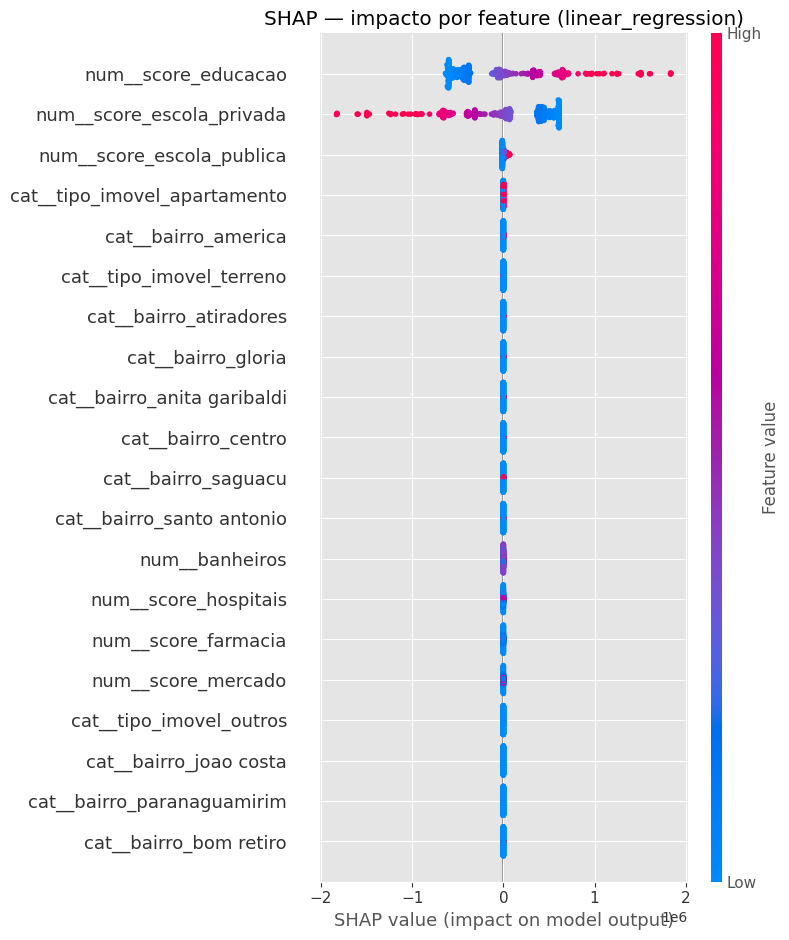

In [89]:
shap.summary_plot(
    shap_values,
    X_ex_shap,
    feature_names=nomes_features_shap,
    show=False,
    max_display=20,
)
plt.title(f"SHAP — impacto por feature ({modelo_shap_nome})")
plt.tight_layout()
plt.show()

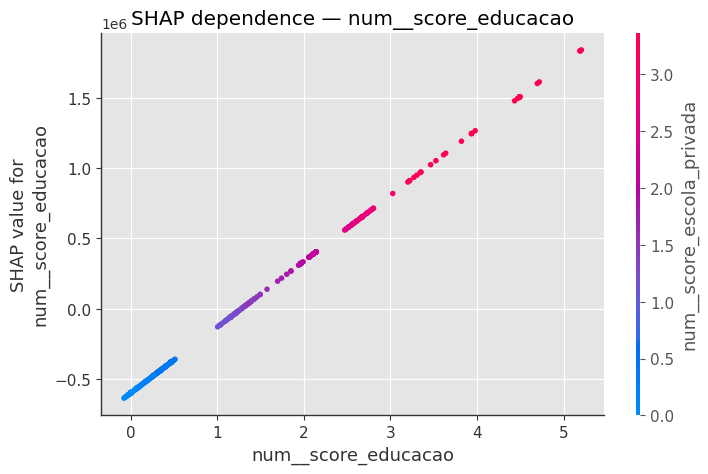

In [90]:
# Gráfico de dependência da feature mais importante
feature_top = importancia_shap.index[0]
shap.dependence_plot(
    feature_top,
    shap_values,
    X_ex_shap,
    feature_names=nomes_features_shap,
    show=False,
)
plt.title(f"SHAP dependence — {feature_top}")
plt.tight_layout()
plt.show()

## Exemplos de previsão no conjunto de teste

In [97]:
NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]

['banheiros',
 'vagas',
 'quartos',
 'score_escola_privada',
 'score_escola_publica',
 'score_hospitais',
 'score_mercado',
 'score_farmacia',
 'score_parque',
 'score_seguranca',
 'score_educacao',
 'tipo_imovel',
 'bairro',
 'preco_por_m2']

In [99]:
if melhor_modelo == "keras_mlp":
    pred_test = np.expm1(modelo_final_keras.predict(pipeline_final.transform(X_test), verbose=0).ravel())
else:
    pred_test = pipeline_final.predict(X_test)

exemplos = pd_joinville.loc[X_test.index, NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET]
].copy()
exemplos["preco_previsto"] = pred_test.round(0).astype(int)
exemplos["erro_abs"] = (exemplos[f"{TARGET}"] - exemplos["preco_previsto"]).abs()
exemplos["erro_pct"] = (exemplos["erro_abs"] / exemplos[f"{TARGET}"] * 100).round(1)

exemplos.sort_values("erro_pct").tail(200)

,banheiros,vagas,quartos,score_escola_privada,score_escola_publica,score_hospitais,score_mercado,score_farmacia,score_parque,score_seguranca,score_educacao,tipo_imovel,bairro,preco_por_m2,preco_previsto,erro_abs,erro_pct
15963,5,2,2,2.719827,0.239435,0.330539,0.195379,0.059246,7.914218,0.668509,2.671940,casa,anita garibaldi,3750.000000,7343,3593.000000,95.8
14844,2,1,2,1.270232,0.120186,0.800109,0.758315,0.096357,6.474573,1.100432,1.246195,apartamento,anita garibaldi,4299.065421,8422,4122.934579,95.9
5843,0,0,0,0.347694,0.049955,0.954131,0.100809,0.082077,4.915170,0.711304,0.337703,terreno,atiradores,2193.645991,4300,2106.354009,96.0
6308,0,0,0,0.496352,0.122887,0.090348,0.711936,0.193922,41.926023,1.392686,0.471775,terreno,floresta,519.832985,1022,502.167015,96.6
9559,4,2,4,4.561073,0.019481,2.029991,0.163855,0.556985,18.276684,1.022159,4.557176,apartamento,atiradores,5205.992509,10255,5049.007491,97.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2172,5,3,4,3.919260,0.019850,1.469859,0.232573,0.794923,25.173699,1.853151,3.915290,apartamento,anita garibaldi,458.000000,8787,8329.000000,1818.6
25593,1,0,1,0.378215,0.149957,0.291746,0.145477,0.053432,7.291150,0.567817,0.348224,casa,pirabeiraba,233.333333,4899,4665.666667,1999.6
686,1,0,1,0.088329,0.022875,0.046264,0.002795,0.422523,0.243675,0.579944,0.083754,galpao,distrito industrial,105.809782,3895,3789.190218,3581.1
2021,2,2,4,0.052035,0.054975,0.081028,0.062401,0.000848,0.130733,0.285089,0.041040,rural,pirabeiraba,210.000000,8444,8234.000000,3921.0


In [100]:
exemplos[exemplos['erro_pct'] <= 60].sort_values("erro_pct").tail(50)

,banheiros,vagas,quartos,score_escola_privada,score_escola_publica,score_hospitais,score_mercado,score_farmacia,score_parque,score_seguranca,score_educacao,tipo_imovel,bairro,preco_por_m2,preco_previsto,erro_abs,erro_pct
12543,2,2,3,0.173921,0.530745,2.654435e-02,0.726853,0.447244,3.345352e+00,1.063597e+00,0.067772,casa,vila nova,3488.372093,5398,1909.627907,54.7
23581,3,3,3,0.000000,0.000000,1.084448e-254,0.000000,0.000000,4.087074e-251,1.100512e-202,0.000000,casa,guanabara,3004.016064,4648,1643.983936,54.7
11807,2,4,4,0.368691,0.179262,6.175199e-02,0.791963,0.080939,2.281589e+00,5.500797e-01,0.332838,casa,floresta,3136.363636,4858,1721.636364,54.9
1301,2,16,3,2.162374,0.121141,3.153187e-01,0.188179,0.111285,5.676289e+00,2.590724e-01,2.138146,casa,iririu,3250.000000,5044,1794.000000,55.2
538,0,0,0,0.372396,0.096938,1.267186e-01,0.702099,0.123399,4.253523e+01,6.694322e-01,0.353009,terreno,floresta,700.035271,1087,386.964729,55.3
22785,1,1,3,3.204130,0.009503,1.950567e+00,0.748138,1.248916,7.519607e+00,1.042548e+00,3.202229,apartamento,america,6052.631579,9397,3344.368421,55.3
23948,4,4,4,0.000000,0.000000,5.990097e-195,0.000000,0.000000,6.248962e-192,1.958121e-154,0.000000,casa,guanabara,3038.461538,4727,1688.538462,55.6
26339,1,1,1,2.738146,0.018194,9.808461e-01,0.241610,0.154703,1.205169e+01,1.127918e+00,2.734507,apartamento,america,6333.333333,9872,3538.666667,55.9
2649,2,2,2,0.347694,0.049955,9.541307e-01,0.100809,0.082077,4.915170e+00,7.113041e-01,0.337703,apartamento,atiradores,6250.000000,9750,3500.000000,56.0
4000,0,0,0,1.961237,0.104936,9.125067e-01,0.711227,0.112620,3.828426e+00,6.214911e-01,1.940250,terreno,costa e silva,1191.066998,1858,666.933002,56.0


In [74]:
exemplos[exemplos['erro_pct'] <= 60].sort_values("erro_pct").tail(50)["url"].tolist()

['https://www.chavesnamao.com.br/imovel/terreno-em-condominio-a-venda-sc-joinville-espinheiros-200m2-RS320000/id-34871877/',
 'https://www.chavesnamao.com.br/imovel/terreno-a-venda-sc-joinville-floresta-3047m2-RS2680000/id-27666227/',
 'https://sc.olx.com.br/norte-de-santa-catarina/imoveis/apartamento-joinville-gloria-1493121825',
 'https://www.zapimoveis.com.br/imovel/venda-terreno-lote-comercial-comasa-joinville-450m2-id-2882639793/?source=ranking%2Crp',
 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-1-quarto-com-garagem-sc-joinville-costa-e-silva-66m2-RS280000/id-29564287/',
 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-3-quartos-com-garagem-sc-joinville-anita-garibaldi-144m2-RS550000/id-35817639/',
 'https://sc.olx.com.br/norte-de-santa-catarina/imoveis/casa-joinville-jarivatuba-quartos-3-1491014299',
 'https://www.chavesnamao.com.br/imovel/casa-a-venda-2-quartos-com-garagem-sc-joinville-petropolis-384m2-RS499900/id-28082286/',
 'https://www.chavesnamao.c

<Axes: title={'center': 'preco_previsto médio por bairro'}, ylabel='bairro,tipo_imovel'>

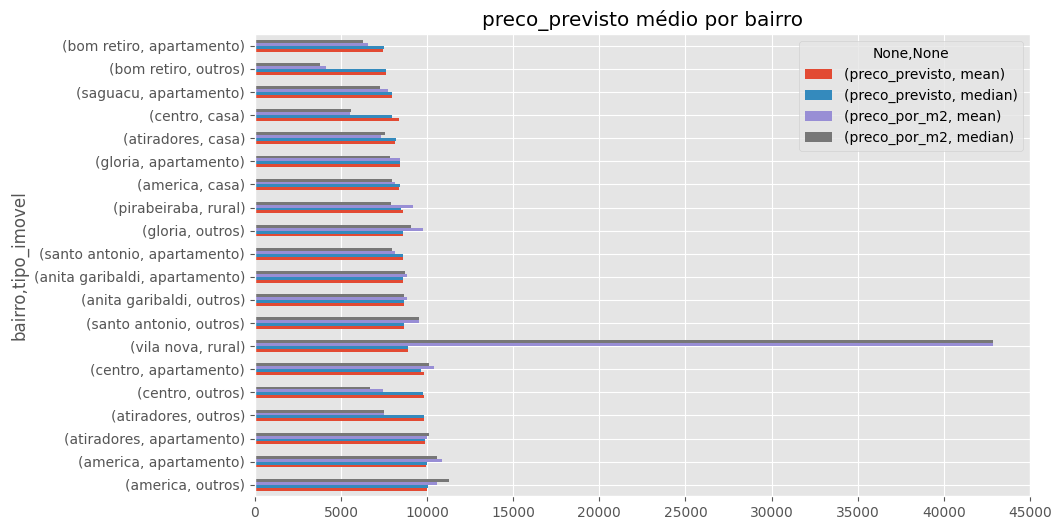

In [101]:
grouped_preco_previsto_bairro = exemplos.groupby(["bairro", "tipo_imovel"]).aggregate({"preco_previsto": [
                                                                                            "mean", 
                                                                                           "median"
                                                                                           ],
                                                                        "preco_por_m2": [
                                                                            "mean", 
                                                                            "median"]})#.sort_values("erro_pct", ascending=False)

grouped_preco_previsto_bairro.sort_values(("preco_previsto", "median"), ascending=False).head(20).plot(kind="barh", figsize=(10, 6), title="preco_previsto médio por bairro")

<Axes: title={'center': 'Erro percentual médio por bairro'}, ylabel='bairro,tipo_imovel'>

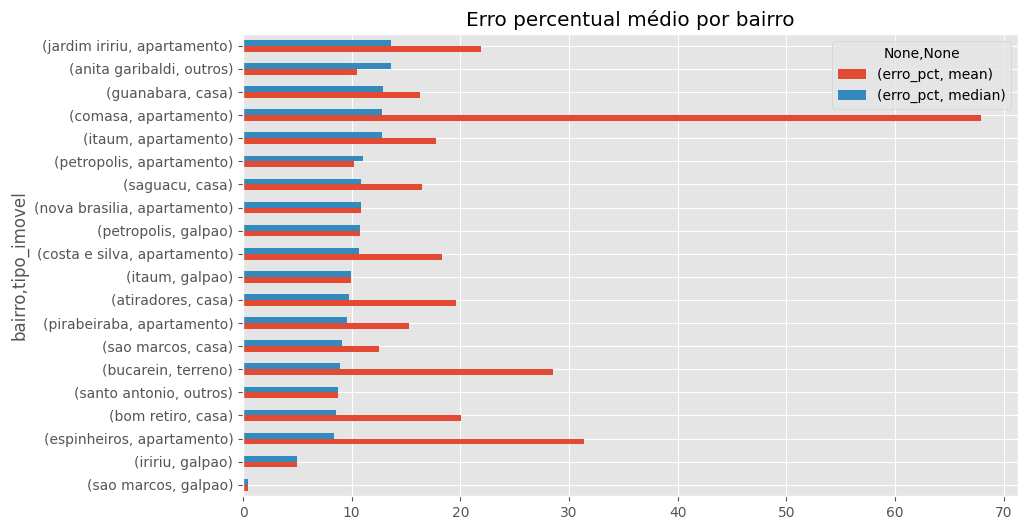

In [102]:
grouped_erro_bairro = exemplos.groupby(["bairro", "tipo_imovel"]).aggregate({"erro_pct": ["mean", "median"]})#.sort_values("erro_pct", ascending=False)

grouped_erro_bairro.sort_values(("erro_pct", "median"), ascending=True).head(20).plot(kind="barh", figsize=(10, 6), title="Erro percentual médio por bairro")

In [103]:
bairros = df_modelo["bairro"].unique()
tipos = df_modelo["tipo_imovel"].unique()

metrics_bairro = {}

for bairro in bairros:
    for tipo in tipos:
        try:
            print(f"{bairro} - {tipo} - Métricas por bairro:")
            previsao_bairro = exemplos[(exemplos['bairro'] == bairro) & (exemplos['tipo_imovel'] == tipo)][f"preco_previsto"]
            valor_verdadeiro_bairro = exemplos[(exemplos['bairro'] == bairro) & (exemplos['tipo_imovel'] == tipo)][f"{TARGET}"]
            metrics_bairro[(bairro, tipo)] = metricas(bairro, valor_verdadeiro_bairro, previsao_bairro)
        except Exception as e:
            print(f"Erro ao processar o bairro {bairro}: {e}")
    

joao costa - apartamento - Métricas por bairro:
joao costa: RMSE=R$ 1,160 | MAE=R$ 958 | MAPE=24.0% | R²=-0.359
joao costa - comercial - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
joao costa - casa - Métricas por bairro:
joao costa: RMSE=R$ 1,519 | MAE=R$ 1,215 | MAPE=41.2% | R²=-0.021
joao costa - outros - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
joao costa - terreno - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
joao costa - rural - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
joao costa - galpao - Métricas por bairro:
Erro ao processar o bairro joao costa: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 i

In [104]:
metrics_bairro_df = pd.DataFrame(metrics_bairro).T.sort_values("mape", ascending=True)
metrics_bairro_df.head(40)

,,rmse,mae,mape,r2
sao marcos,galpao,23.000000,23.000000,0.525714,NaN
iririu,galpao,194.207921,194.207921,4.953283,NaN
santo antonio,outros,991.347757,850.072909,8.706755,-3.820022
itaum,galpao,428.826087,428.826087,9.863000,NaN
petropolis,apartamento,619.301067,591.759213,10.178687,0.161716
anita garibaldi,outros,1121.532717,944.303855,10.510183,-0.106321
nova brasilia,apartamento,738.371699,557.499278,10.830022,-0.322198
petropolis,galpao,460.968254,460.968254,10.836194,NaN
sao marcos,casa,1232.659698,842.877396,12.488850,-0.227199
nova brasilia,galpao,633.428571,633.428571,13.856250,NaN


In [75]:
result = comparar_modelos_mlflow("imoveis-joinville")

Usando experimento encontrado: /Users/sehnemjeferson@gmail.com/imoveis-joinville (ID: 812916905475604)
Comparação de modelos treinados:
                       run_name          rmse          mae     mape            r2                                                                                                                                                                                                                                                                                                        parametros                                                                                                                                                                           feature_sampled                 modelo   status
             mlp_keras_trial_14   2377.910853  1521.162501 0.332705      0.483615                                                                                                    {'batch_size': '256', 'dropout_0': '0.2', 'dropout_1': '0.1', 'dropout_2': '0

In [79]:
result.sort_values("rmse").head(10)

,run_name,rmse,mae,mape,r2,parametros,feature_sampled,modelo,status
15,mlp_keras_trial_14,2377.910853,1521.162501,0.332705,0.483615,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
0,mlp_keras_trial_29,2387.156411,1543.907826,0.351104,0.479592,"{'batch_size': '64', 'dropout_0': '0.2', 'drop...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
13,mlp_keras_trial_16,2392.118165,1531.975325,0.330038,0.477426,"{'batch_size': '256', 'dropout_0': '0.30000000...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
1,mlp_keras_trial_28,2463.746242,1591.172340,0.358177,0.445663,"{'batch_size': '64', 'dropout_0': '0.2', 'drop...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
26,mlp_keras_trial_3,2464.997878,1589.413535,0.336173,0.445099,"{'batch_size': '256', 'dropout_0': '0.30000000...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
16,mlp_keras_trial_13,2467.734696,1626.610526,0.362470,0.443866,"{'batch_size': '128', 'dropout_0': '0.2', 'lea...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
3,mlp_keras_trial_26,2474.324773,1622.943383,0.345100,0.440892,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
7,mlp_keras_trial_22,2539.662974,1705.378538,0.361937,0.410974,"{'batch_size': '256', 'dropout_0': '0.2', 'dro...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
8,mlp_keras_trial_21,2542.342571,1638.215585,0.347782,0.409731,"{'batch_size': '256', 'dropout_0': '0.30000000...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
25,mlp_keras_trial_4,2596.030881,1729.714083,0.385918,0.384537,"{'batch_size': '128', 'dropout_0': '0.0', 'lea...","banheiros, vagas, quartos, score_escola_privad...",keras,FINISHED
